# 2일차 8교시 실습 · 영상 처리 시간과 FPS 측정
강의자료 PDF 1~14페이지. A·B 두 빈칸을 채운 뒤 위에서 아래로 실행합니다.

노트북과 `timing_helpers.py`, `practice_views.py`, `data` 폴더를 같은 폴더에 둡니다. 화면 표시 비교는 OpenCV 창을 띄울 수 있는 로컬 Jupyter 환경에서 실행합니다.


In [1]:
# 실제 현업에서 자주 고민하는 부분 중 하나라고 함. 시간과 관련된...

from pathlib import Path
from time import perf_counter
from timing_helpers import (
    run_once, benchmark, print_results, print_stages, print_quality,
    plot_results, compare_frames, save_preview,
)
from practice_views import (
    plot_stages, show_crop_comparison, save_measurements,
    plot_fps, show_sizes,
)

data = Path("data")
video = data / "normal.avi"

## 시간 측정과 FPS 계산 · 강의자료 PDF 3·4·6페이지
A는 현재 기준값을 초 단위로 읽는 함수 호출입니다. 두 호출의 차이가 경과 시간입니다. B는 완료 프레임 수를 경과 시간으로 나눕니다.

아래 120프레임과 2초는 계산 확인을 위한 설명용 값입니다.


In [3]:
def now():
    return perf_counter  # A: PPT 3

def fps_from(n, elapsed):
    return n/elapsed  # B: PPT 4

print(fps_from(120, 2))

60.0


## 한 번 실행해 측정한다 · 강의자료 PDF 6페이지
입력은 576×320, 30FPS 영상의 121프레임입니다. 이번 실행은 화면 표시와 키 입력 대기를 제외합니다. 결과를 그리는 단계는 수행합니다. 출력 시간은 초(`s`), 처리 속도는 `FPS`입니다.

이 셀은 1회만 실행합니다. 강의자료 PDF 6·7페이지의 숫자는 반복 측정에서 고른 대표 예시이며, 이 셀에서 같은 숫자가 나와야 하는 것은 아닙니다.


In [8]:
baseline = run_once(video, now(), fps_from, scale=1.0, display=False)
print("Completed:", baseline["completed"])
print(f"Elapsed: {baseline['elapsed_s']:.3f} s")
print(f"Processing: {baseline['fps']:.1f} FPS")

Completed: 121
Elapsed: 0.463 s
Processing: 261.5 FPS


## 구간별 시간을 확인한다 · 강의자료 PDF 7페이지
단위는 프레임당 평균 밀리초(`ms`)이며 1초는 1000ms입니다. `read`는 읽기, `detect`는 크기 조절·후보 검출, `link`는 위치 연결, `draw`는 그리기, `display`는 표시·키 입력 대기, `other`는 기록·반복문 등의 나머지 시간입니다. 분석 시간은 `detect + link`입니다.


Stage mean time per frame (ms)
read    : 3.038
detect  : 0.574
link    : 0.051
draw    : 0.153
display : 0.000
other   : 0.007
total   : 3.823


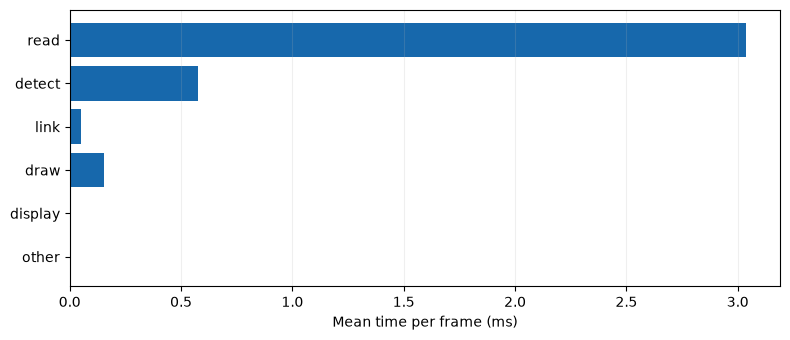

In [9]:
print_stages(baseline)
plot_stages(baseline)

## 표시 여부를 비교한다 · 강의자료 PDF 8페이지
제공 함수가 각 조건을 한 번 준비 실행한 뒤 세 번씩 기록합니다. 조건은 576×320 표시 끔, 576×320 표시 켬, 288×160 표시 끔입니다. 매 실행 영상 시작 위치와 추적 상태를 초기화합니다.

표시 켬에서는 OpenCV 창이 나타납니다. 처리가 끝나면 닫힙니다. 표시 끔과 켬 모두 결과 그림을 만들며, 켬에서는 화면 표시와 키 입력 대기를 추가합니다. 아래 표의 `display=True`가 표시 켬입니다.


size      display  run  frames  seconds    FPS   ms/frame
576x320   False     1    121    0.426   283.8     3.524
576x320   False     2    121    0.414   292.3     3.421
576x320   False     3    121    0.423   286.1     3.496
576x320   True      1    121    1.473    82.1    12.176
576x320   True      2    121    1.479    81.8    12.224
576x320   True      3    121    1.507    80.3    12.456


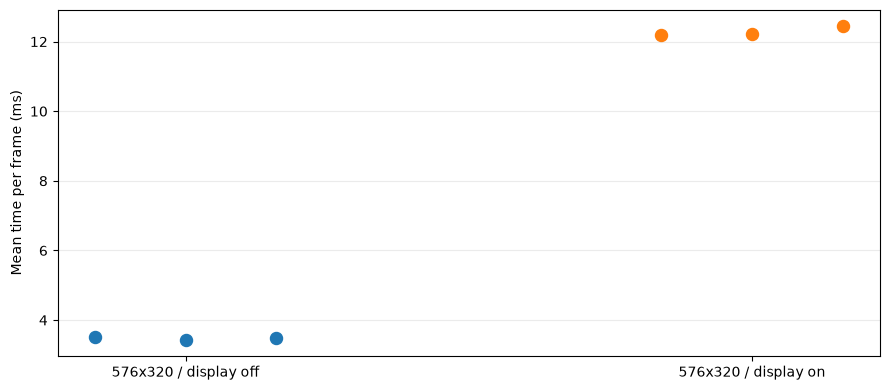

In [11]:
results = benchmark(video, now(), fps_from, repeats=3, display=True)
display_runs = [r for r in results if r["scale"] == 1.0]
print_results(display_runs)
plot_results(display_runs)

## 같은 조건의 세 번 실행을 비교한다 · 강의자료 PDF 9페이지
앞에서 측정한 576×320·표시 끔의 세 결과를 읽습니다. 시간과 FPS는 같은 실행에서 나온 값입니다. 다른 프로그램 실행 상태 등에 따라 결과가 달라질 수 있습니다.

그래프의 가로축은 1·2·3회, 세로축은 처리 FPS입니다. 막대가 높을수록 처리 속도가 빠릅니다.


size      display  run  frames  seconds    FPS   ms/frame
576x320   False     1    121    0.426   283.8     3.524
576x320   False     2    121    0.414   292.3     3.421
576x320   False     3    121    0.423   286.1     3.496


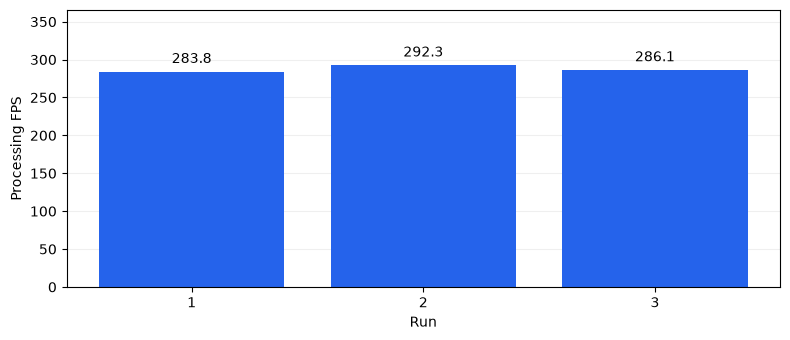

In [ ]:
repeated = [r for r in results if r["scale"] == 1.0 and not r["display"]]
print_results(repeated)
plot_fps(repeated)

#여러번 테스트했을때의 모습. 거의 일정한 모습이다.

## 처리 크기를 비교한다 · 강의자료 PDF 10페이지
표시를 끈 두 크기를 비교합니다. 축소 비용은 `detect` 시간에 포함합니다. 후보 면적과 대표 좌표는 576×320 기준으로 환산한 뒤 기존 면적·거리 조건을 적용합니다. 읽기와 결과 그리기는 두 조건 모두 원래 크기를 사용합니다.

제공 함수 show_sizes는 크기별 3회 중 전체 반복 시간이 가운데인 실행을 고릅니다. 그 실행의 검출 시간·전체 평균 시간·FPS를 함께 출력합니다. Detect는 검출 시간, Total은 전체 평균 시간이며 둘 다 ms/프레임 단위입니다.


In [13]:
size_runs = [r for r in results if not r["display"]]
size_summary = show_sizes(size_runs)

Size      Run  Detect(ms/frame)  Total(ms/frame)  Processing FPS
576x320     3             0.585            3.496           286.1
288x160     3             0.317            3.387           295.2


## 같은 장면의 결과를 비교한다 · 강의자료 PDF 11페이지
클립 내부 80번 프레임은 원본의 100번 프레임입니다. 두 번호 모두 0부터 셉니다. 검출 결과와 마스크를 같은 크기로 표시하고, 두 조건의 같은 영역을 확대합니다. 축소한 마스크를 표시용으로 키울 때는 최근접 보간을 사용합니다.


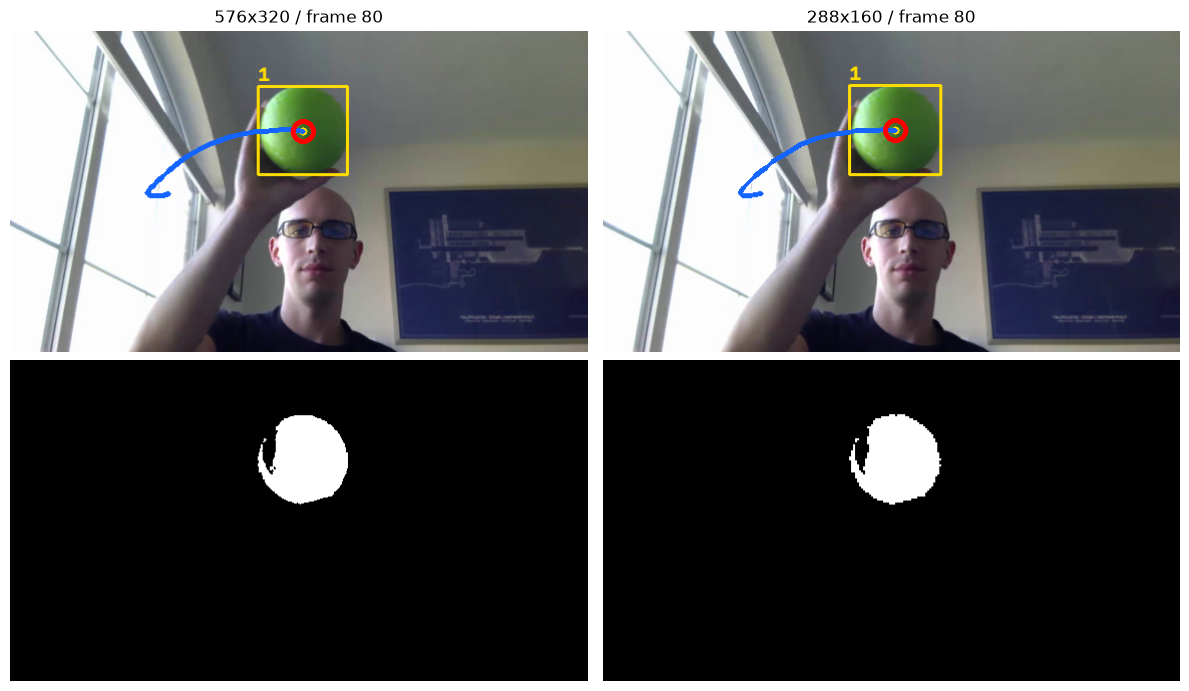

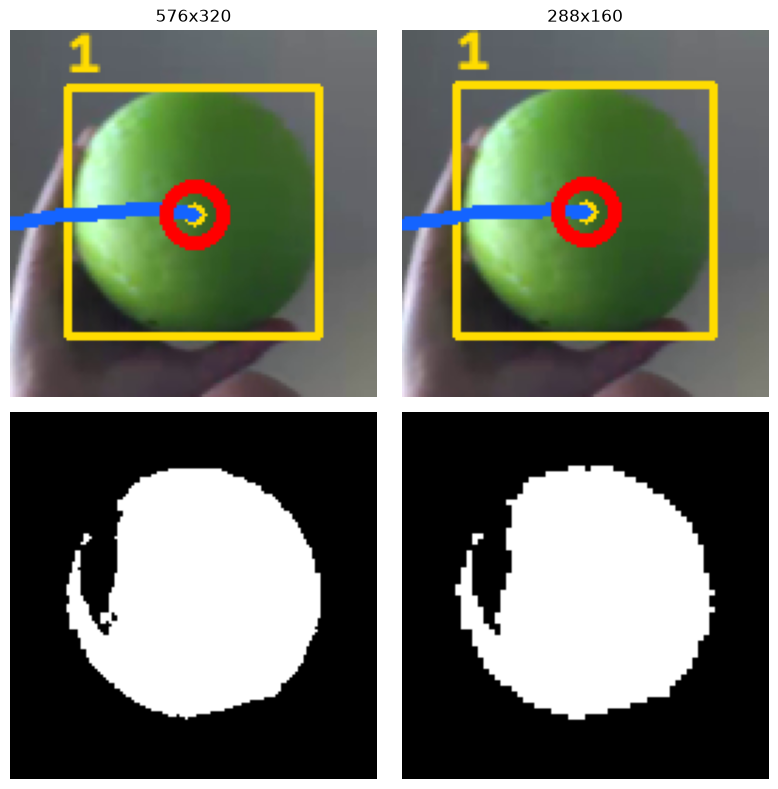

size      display  run  candidate_frames  linked  selected_frames
576x320   False     1               121     120              121
576x320   False     2               121     120              121
576x320   False     3               121     120              121
288x160   False     1               121     120              121
288x160   False     2               121     120              121
288x160   False     3               121     120              121


In [14]:
previews = compare_frames(video, frame_index=80)
show_crop_comparison(previews)
print_quality(size_runs)

후보가 있는 프레임 수는 `candidate_frames`, 이전 위치와 연결한 횟수는 `linked`, 위치가 정해진 프레임 수는 `selected_frames`입니다. 첫 시작도 위치가 정해진 프레임에 포함합니다. 이 수치는 정답 라벨과 비교한 인식 정확도가 아닙니다.


## 측정값과 처리 결과를 함께 남긴다 · 강의자료 PDF 14페이지
측정표는 `outputs/measurements.csv`로 저장합니다. 두 조건의 결과 영상은 측정을 마친 뒤 별도로 생성합니다. 저장 시간은 앞의 FPS 계산에 포함하지 않습니다. 결과 영상의 재생 FPS는 원본과 같은 30입니다.


In [15]:
print_results(results)
print_quality(results)
print(save_measurements(results))
print("Full-size frames:", save_preview(video, scale=1.0, output="outputs/full.avi"))
print("Half-size frames:", save_preview(video, scale=0.5, output="outputs/half.avi"))

size      display  run  frames  seconds    FPS   ms/frame
576x320   False     1    121    0.426   283.8     3.524
576x320   False     2    121    0.414   292.3     3.421
576x320   False     3    121    0.423   286.1     3.496
576x320   True      1    121    1.473    82.1    12.176
576x320   True      2    121    1.479    81.8    12.224
576x320   True      3    121    1.507    80.3    12.456
288x160   False     1    121    0.422   286.7     3.488
288x160   False     2    121    0.401   302.0     3.311
288x160   False     3    121    0.410   295.2     3.387
size      display  run  candidate_frames  linked  selected_frames
576x320   False     1               121     120              121
576x320   False     2               121     120              121
576x320   False     3               121     120              121
576x320   True      1               121     120              121
576x320   True      2               121     120              121
576x320   True      3               121     120